In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [18]:
dataset = pd.read_csv('iris.csv')
dataset.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [19]:
# X -> Özellikler, y -> Gerçek sınıflar
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [20]:
# 2) Ölçekleme
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

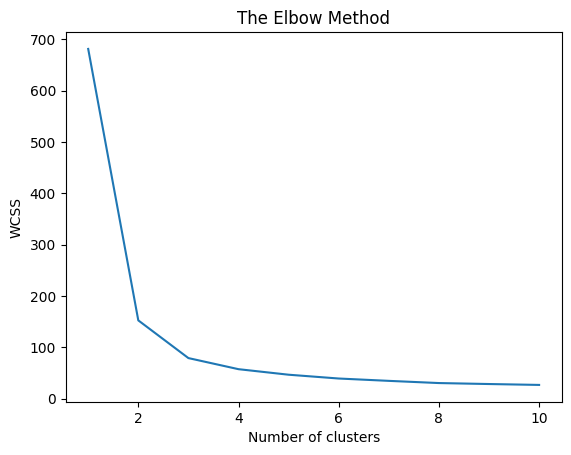

In [21]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X) #sadece özelliklere gerek olduğundan
    wcss.append(kmeans.inertia_) #intertia_ Sum of squared distances of samples to their closest cluster center, weighted by the sample weights if provided.
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()
# kaç tane clustor oluşturacağımızı tespit etmek için elbow methodunu uyguluyorus

In [22]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 0)
y_kmeans = kmeans.fit_predict(X_scaled)

In [23]:
# 4) Boyutu 2D'ye düşürüp görselleştirme (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [24]:
plt.figure(figsize=(8,4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

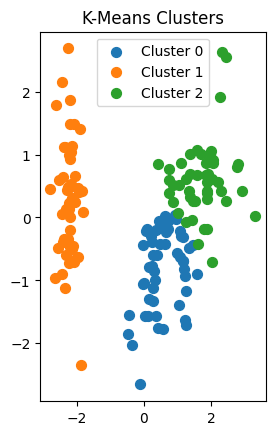

In [25]:
# Cluster görselleştirme
plt.subplot(1,2,1)
plt.scatter(X_pca[y_kmeans == 0, 0], X_pca[y_kmeans == 0, 1], s=50, label='Cluster 0')
plt.scatter(X_pca[y_kmeans == 1, 0], X_pca[y_kmeans == 1, 1], s=50, label='Cluster 1')
plt.scatter(X_pca[y_kmeans == 2, 0], X_pca[y_kmeans == 2, 1], s=50, label='Cluster 2')
plt.title("K-Means Clusters")
plt.legend()

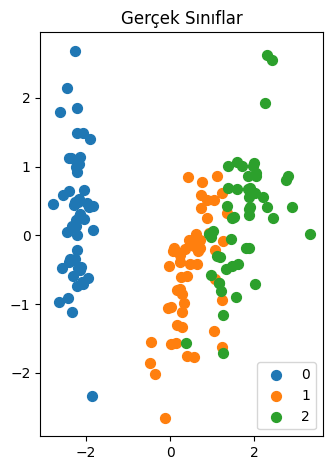

In [26]:
# Gerçek etiketler
plt.subplot(1,2,2)
classes = np.unique(y)
for i, c in enumerate(classes):
    plt.scatter(X_pca[y == c, 0], X_pca[y == c, 1], s=50, label=c)
plt.title("Gerçek Sınıflar")
plt.legend()

plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import confusion_matrix, accuracy_score
from scipy.stats import mode

# Cluster → sınıf mapping
labels = np.zeros_like(y_kmeans)
for i in range(3):
    mask = (y_kmeans == i)
    labels[mask] = mode(y[mask])[0]  # Her cluster’ın en sık görülen gerçek sınıfı

# Confusion matrix ve accuracy
cm = confusion_matrix(y, labels)
acc = accuracy_score(y, labels)

print("Confusion Matrix:\n", cm)
print("Accuracy:", acc)

Confusion Matrix:
 [[50  0  0]
 [ 0 39 11]
 [ 0 14 36]]
Accuracy: 0.8333333333333334


**K-Means gibi clustering algoritmaları** tamamen *unsupervised* (gözetimsiz) çalışır, yani eğitim sırasında **`y` etiketlerini hiç kullanmaz**.
Sen burada `y`’yi sadece **“eldeki veriyle, gerçek etiketlere ne kadar yakın çalışıyor”** diye test etmek için kullanıyorsun.

Gerçek hayatta:

* Elinde **yok** → `y` bilinmiyor, o yüzden **accuracy, confusion matrix gibi supervised metrikler** kullanamazsın.
* Bunun yerine şu metrikler kullanılır:

---

## 📊 Clustering’de kullanılan **unsupervised metrikler**

1. **Silhouette Score**

   * Küme içi benzerlik ve kümeler arası ayrımı ölçer.
   * `-1` ile `1` arasında değer alır. `1` → mükemmel ayrım, `0` → kümeler üst üste binmiş, negatif → hatalı kümeleme.

In [33]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, y_kmeans)
print("Silhouette Score:", score)

Silhouette Score: 0.45994823920518646


3. **Calinski-Harabasz Index**

   * Daha yüksek değer iyidir.

In [34]:
from sklearn.metrics import calinski_harabasz_score
ch_score = calinski_harabasz_score(X_scaled, y_kmeans)
print("Calinski-Harabasz Index:", ch_score)

Calinski-Harabasz Index: 241.90440170183172


2. **Davies-Bouldin Index**

   * Daha düşük değer iyidir.

In [35]:
from sklearn.metrics import davies_bouldin_score
db_score = davies_bouldin_score(X_scaled, y_kmeans)
print("Davies-Bouldin Index:", db_score)

Davies-Bouldin Index: 0.8335949464754334



💡 **Özet:**

* Eğer veri **etiketli** (y var) → supervised metrikler (accuracy, f1, confusion matrix) kullanabilirsin.
* Eğer veri **etiketsiz** (y yok) → clustering metrikleri (silhouette, Davies-Bouldin, Calinski-Harabasz, vb.) kullanılır.
* Gerçek hayatta `y` yoksa accuracy diye bir şey yok, modelin başarısını yukarıdaki unsupervised metriklerle ölçersin.